# Importing data and libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv("mtsamples.csv", encoding= 'utf-8')

# Data exploration

In [3]:
data.head(5)

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [4]:
print(f'data shape is: {data.shape}')

data shape is: (4999, 6)


## Finding and removing NaN values

In [5]:
data.isna().sum()

Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

In [6]:
print(f"description",data['description'].isna().sum())
print(f"medical_specialty",data['medical_specialty'].isna().sum())
print(f"sample_name",data['sample_name'].isna().sum())
print(f"transcription",data['transcription'].isna().sum())
print(f"keywords",data['keywords'].isna().sum())

description 0
medical_specialty 0
sample_name 0
transcription 33
keywords 1068


In [7]:
# drop rows that contain NaN values
data = data.dropna()
print(data.shape)

(3898, 6)


<Axes: xlabel='medical_specialty'>

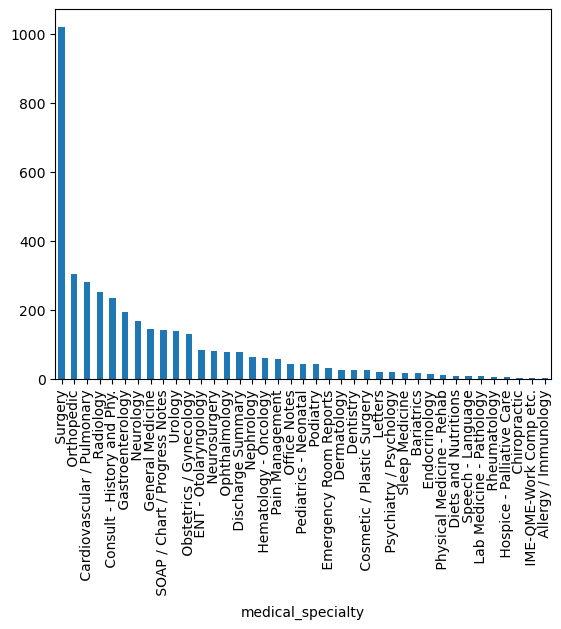

In [8]:
data['medical_specialty'].value_counts().plot(kind='bar')

Let's consider the top 25 medical specialties with the most representative values within the dataset.

In [9]:
spec_count=data['medical_specialty'].value_counts()[0:25]
spec_count

medical_specialty
Surgery                          1021
Orthopedic                        303
Cardiovascular / Pulmonary        280
Radiology                         251
Consult - History and Phy.        234
Gastroenterology                  195
Neurology                         168
General Medicine                  146
SOAP / Chart / Progress Notes     142
Urology                           140
Obstetrics / Gynecology           130
ENT - Otolaryngology               84
Neurosurgery                       81
Ophthalmology                      79
Discharge Summary                  77
Nephrology                         63
Hematology - Oncology              62
Pain Management                    58
Office Notes                       44
Pediatrics - Neonatal              42
Podiatry                           42
Emergency Room Reports             31
Dermatology                        25
Dentistry                          25
Cosmetic / Plastic Surgery         25
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2c801164d70>,
 [Text(0.7211699908028784, 0.8306105250750058, ' Surgery'),
  Text(-0.42308036332241994, 1.015383181942152, ' Orthopedic'),
  Text(-0.8502383205336055, 0.6979217709000016, ' Cardiovascular / Pulmonary'),
  Text(-1.0678830512213315, 0.26386699095229654, ' Radiology'),
  Text(-1.0851885346241097, -0.17990509809446126, ' Consult - History and Phy.'),
  Text(-0.9524741006382815, -0.550266378777858, ' Gastroenterology'),
  Text(-0.7438663616683107, -0.8103473551375052, ' Neurology'),
  Text(-0.5074233854123258, -0.9759720835847173, ' General Medicine'),
  Text(-0.2593888434346928, -1.068979619965513, ' SOAP / Chart / Progress Notes'),
  Text(-0.0018436768916101013, -1.099998454933242, ' Urology'),
  Text(0.24503035023451594, -1.0723619386494239, ' Obstetrics / Gynecology'),
  Text(0.4324246558994411, -1.0114390327499974, ' ENT - Otolaryngology'),
  Text(0.5677353905221167, -0.9421658698704277, ' Neurosurgery'),
  Text(0.6886158278322797, -0.857

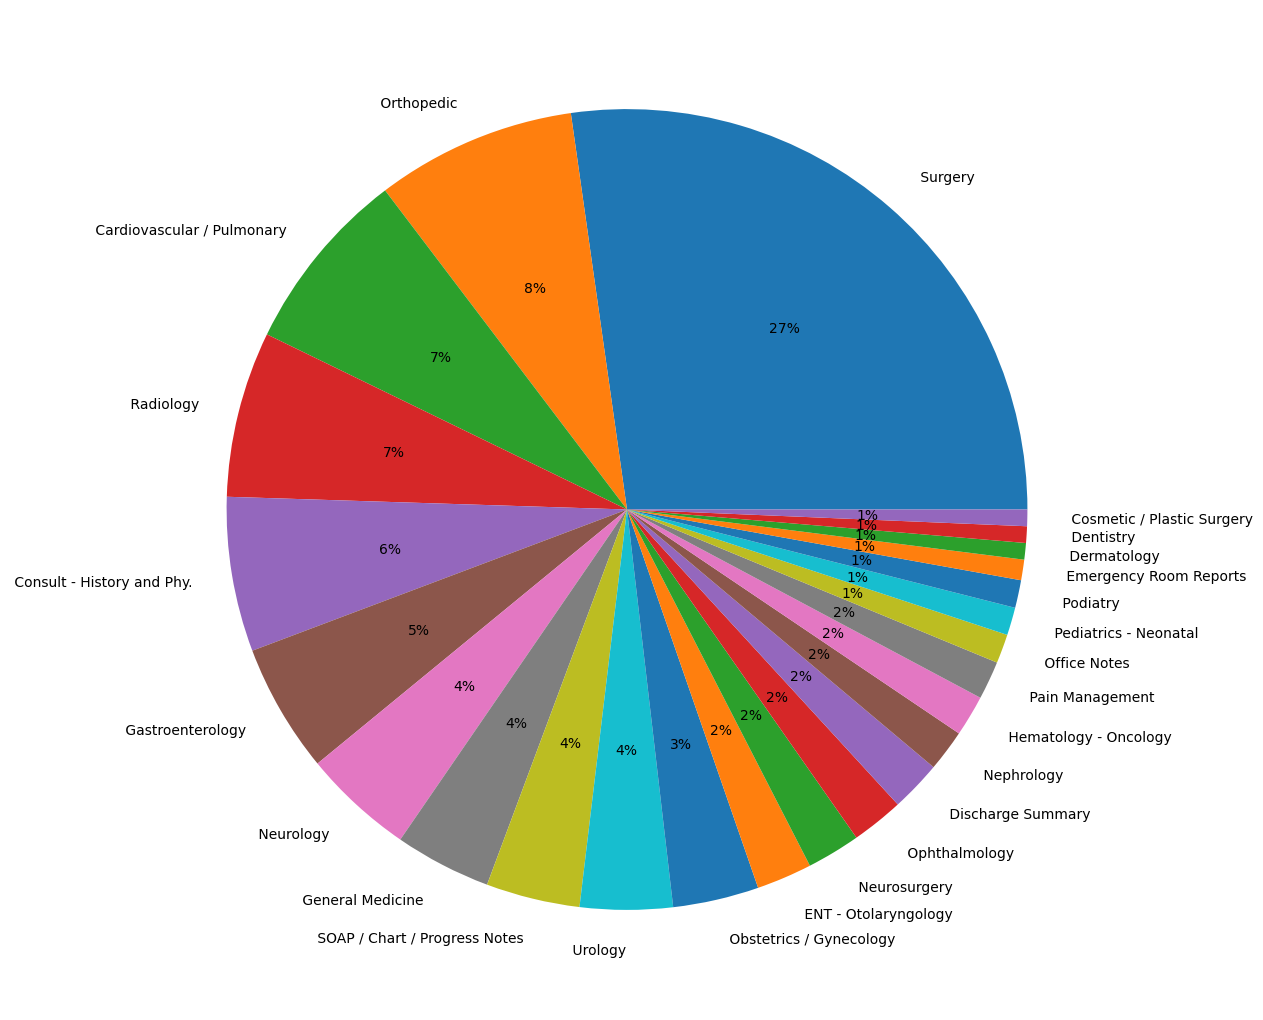

In [10]:
plt.figure(figsize=(13,13))
# Plotting the pie chart for above dataframe
plt.pie(spec_count,labels=list(spec_count.index),autopct='%1.0f%%')

## Shaping dataset

We select only **medical_specialty** and **transcription** which are the coloumns we are gonna work with.

In [11]:
data = data[['medical_specialty','transcription']]
data.head()

,medical_specialty,transcription
0,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...


In [12]:
def shape(data,data_name):
    print(f'STATUS: Dimension of "{data_name}" = {data.shape}')

In [13]:
df_obj = data.select_dtypes(['object'])
data[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())

We choose to work only on five **medical_specialty**

In [14]:
data = data[data['medical_specialty'].isin(['Orthopedic', 'Cardiovascular / Pulmonary','Consult - History and Phy.', 'Gastroenterology','Neurology'])]
shape(data,'data')

STATUS: Dimension of "data" = (1180, 2)


In [15]:
data.head(5)

,medical_specialty,transcription
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...
7,Cardiovascular / Pulmonary,"2-D ECHOCARDIOGRAM,Multiple views of the heart..."
9,Cardiovascular / Pulmonary,"DESCRIPTION:,1. Normal cardiac chambers size...."
11,Cardiovascular / Pulmonary,"2-D STUDY,1. Mild aortic stenosis, widely calc..."


# Classification pre-processing

## Text pre-processing

Lower-casing, removing punctuation and numbers

In [16]:
#defining the function to remove punctuation
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree

def character_repeatation(text):
    # Pattern matching for all case alphabets
    # \1   It refers to the first capturing group.
    # {1,} It means we are matching for repetition that occurs more than one time.
    # r’\1\1' → It limits all the repetition to two characters.
    Pattern_alpha = re.compile(r"([A-Za-z])\1{1,}", re.DOTALL)
    # Limiting all the  repeatation to two characters.
    Formatted_text = Pattern_alpha.sub(r"\1\1", text)
    # Pattern matching for all the punctuations that can occur
    Pattern_Punct = re.compile(r'([.,/#!$%^&*?;:{}=_`~()+-])\1{1,}')
    # Limiting punctuations in previously formatted string to only one.
    Combined_Formatted = Pattern_Punct.sub(r'\1', Formatted_text)
    return Combined_Formatted

In [17]:
display(data.head(5))
data['transcription']= data['transcription'].apply(lambda x: remove_punctuation(x))
data['transcription']= data['transcription'].apply(lambda x: character_repeatation(x))
data['transcription']= data['transcription'].apply(lambda x: x.lower())
data['transcription']= data['transcription'].apply(lambda x: re.sub(r'\d+', '', x))
display(data.head(5))

,medical_specialty,transcription
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...
7,Cardiovascular / Pulmonary,"2-D ECHOCARDIOGRAM,Multiple views of the heart..."
9,Cardiovascular / Pulmonary,"DESCRIPTION:,1. Normal cardiac chambers size...."
11,Cardiovascular / Pulmonary,"2-D STUDY,1. Mild aortic stenosis, widely calc..."


,medical_specialty,transcription
3,Cardiovascular / Pulmonary,d mmode left atrial enlargement with left a...
4,Cardiovascular / Pulmonary,the left ventricular cavity size and wall th...
7,Cardiovascular / Pulmonary,d echocardiogrammultiple views of the heart an...
9,Cardiovascular / Pulmonary,description normal cardiac chambers size nor...
11,Cardiovascular / Pulmonary,d study mild aortic stenosis widely calcified ...


## Tokenezation

In [18]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
data['tokenized_sents'] = data.apply(lambda row: nltk.word_tokenize(str(row['transcription'])), axis=1)

In [20]:
sents_length = data.apply(lambda row: len(row['tokenized_sents']), axis=1)
sents_length.max()

1835

In [21]:
data.head()

,medical_specialty,transcription,tokenized_sents
3,Cardiovascular / Pulmonary,d mmode left atrial enlargement with left a...,"[d, mmode, left, atrial, enlargement, with, le..."
4,Cardiovascular / Pulmonary,the left ventricular cavity size and wall th...,"[the, left, ventricular, cavity, size, and, wa..."
7,Cardiovascular / Pulmonary,d echocardiogrammultiple views of the heart an...,"[d, echocardiogrammultiple, views, of, the, he..."
9,Cardiovascular / Pulmonary,description normal cardiac chambers size nor...,"[description, normal, cardiac, chambers, size,..."
11,Cardiovascular / Pulmonary,d study mild aortic stenosis widely calcified ...,"[d, study, mild, aortic, stenosis, widely, cal..."


## Stop-words removal

In [22]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [24]:
# Exclude stopwords with Python's list comprehension and pandas.DataFrame.apply.
data['stop_words'] = data['tokenized_sents'].apply(lambda x: ' '.join([word for word in x if word not in (stopwords)]))
data['stop_words'] = data.apply(lambda row: nltk.word_tokenize(str(row['stop_words'])), axis=1)

In [25]:
data.head()

,medical_specialty,transcription,tokenized_sents,stop_words
3,Cardiovascular / Pulmonary,d mmode left atrial enlargement with left a...,"[d, mmode, left, atrial, enlargement, with, le...","[mmode, left, atrial, enlargement, left, atria..."
4,Cardiovascular / Pulmonary,the left ventricular cavity size and wall th...,"[the, left, ventricular, cavity, size, and, wa...","[left, ventricular, cavity, size, wall, thickn..."
7,Cardiovascular / Pulmonary,d echocardiogrammultiple views of the heart an...,"[d, echocardiogrammultiple, views, of, the, he...","[echocardiogrammultiple, views, heart, great, ..."
9,Cardiovascular / Pulmonary,description normal cardiac chambers size nor...,"[description, normal, cardiac, chambers, size,...","[description, normal, cardiac, chambers, size,..."
11,Cardiovascular / Pulmonary,d study mild aortic stenosis widely calcified ...,"[d, study, mild, aortic, stenosis, widely, cal...","[study, mild, aortic, stenosis, widely, calcif..."


## Stemming

In [26]:
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize,word_tokenize

ps=PorterStemmer()

In [27]:
data['stemmed'] = data['stop_words'].apply(lambda x: ' '.join([ps.stem(word) for word in x]))
data['stemmed'] = data.apply(lambda row: nltk.word_tokenize(str(row['stemmed'])), axis=1)

In [28]:
data.head()

,medical_specialty,transcription,tokenized_sents,stop_words,stemmed
3,Cardiovascular / Pulmonary,d mmode left atrial enlargement with left a...,"[d, mmode, left, atrial, enlargement, with, le...","[mmode, left, atrial, enlargement, left, atria...","[mmode, left, atrial, enlarg, left, atrial, di..."
4,Cardiovascular / Pulmonary,the left ventricular cavity size and wall th...,"[the, left, ventricular, cavity, size, and, wa...","[left, ventricular, cavity, size, wall, thickn...","[left, ventricular, caviti, size, wall, thick,..."
7,Cardiovascular / Pulmonary,d echocardiogrammultiple views of the heart an...,"[d, echocardiogrammultiple, views, of, the, he...","[echocardiogrammultiple, views, heart, great, ...","[echocardiogrammultipl, view, heart, great, ve..."
9,Cardiovascular / Pulmonary,description normal cardiac chambers size nor...,"[description, normal, cardiac, chambers, size,...","[description, normal, cardiac, chambers, size,...","[descript, normal, cardiac, chamber, size, nor..."
11,Cardiovascular / Pulmonary,d study mild aortic stenosis widely calcified ...,"[d, study, mild, aortic, stenosis, widely, cal...","[study, mild, aortic, stenosis, widely, calcif...","[studi, mild, aortic, stenosi, wide, calcifi, ..."


In [29]:
total_word_count = data['transcription'].str.split().str.len().sum()
nomalized_word_count = sum(data['stop_words'].apply(len))

In [30]:
# Printing the values
print(f"Total word count on original data: {total_word_count}")
print(f"Words after data pre-processing: {nomalized_word_count}")
print(f'Rate:',(nomalized_word_count/total_word_count)*100)

Total word count on original data: 483365
Words after data pre-processing: 282204
Rate: 58.38320937593744


# N-gram representations

In [31]:
from nltk import ngrams

sentence = 'test sentence'
# set n =2 for bi grams
n = 2

bigrams = ngrams(sentence.split(), n)

print(list(bigrams))

[('test', 'sentence')]


In [32]:
def n_gram(n, data):
    new = data['stemmed'].apply(lambda x: ' '.join(x))
    new = new.str.split().apply(lambda x: list(map(' '.join, ngrams(x, n=n))))
    return new

In [33]:
data['unigram'] = n_gram(1, data)
data['bigram'] = n_gram(2, data)
data['trigram'] = n_gram(3, data)

In [34]:
data.head()

,medical_specialty,transcription,tokenized_sents,stop_words,stemmed,unigram,bigram,trigram
3,Cardiovascular / Pulmonary,d mmode left atrial enlargement with left a...,"[d, mmode, left, atrial, enlargement, with, le...","[mmode, left, atrial, enlargement, left, atria...","[mmode, left, atrial, enlarg, left, atrial, di...","[mmode, left, atrial, enlarg, left, atrial, di...","[mmode left, left atrial, atrial enlarg, enlar...","[mmode left atrial, left atrial enlarg, atrial..."
4,Cardiovascular / Pulmonary,the left ventricular cavity size and wall th...,"[the, left, ventricular, cavity, size, and, wa...","[left, ventricular, cavity, size, wall, thickn...","[left, ventricular, caviti, size, wall, thick,...","[left, ventricular, caviti, size, wall, thick,...","[left ventricular, ventricular caviti, caviti ...","[left ventricular caviti, ventricular caviti s..."
7,Cardiovascular / Pulmonary,d echocardiogrammultiple views of the heart an...,"[d, echocardiogrammultiple, views, of, the, he...","[echocardiogrammultiple, views, heart, great, ...","[echocardiogrammultipl, view, heart, great, ve...","[echocardiogrammultipl, view, heart, great, ve...","[echocardiogrammultipl view, view heart, heart...","[echocardiogrammultipl view heart, view heart ..."
9,Cardiovascular / Pulmonary,description normal cardiac chambers size nor...,"[description, normal, cardiac, chambers, size,...","[description, normal, cardiac, chambers, size,...","[descript, normal, cardiac, chamber, size, nor...","[descript, normal, cardiac, chamber, size, nor...","[descript normal, normal cardiac, cardiac cham...","[descript normal cardiac, normal cardiac chamb..."
11,Cardiovascular / Pulmonary,d study mild aortic stenosis widely calcified ...,"[d, study, mild, aortic, stenosis, widely, cal...","[study, mild, aortic, stenosis, widely, calcif...","[studi, mild, aortic, stenosi, wide, calcifi, ...","[studi, mild, aortic, stenosi, wide, calcifi, ...","[studi mild, mild aortic, aortic stenosi, sten...","[studi mild aortic, mild aortic stenosi, aorti..."


In [35]:
%pip install wordcloud
from wordcloud import WordCloud, ImageColorGenerator

def print_wordCloud(input):
  to_print = [item for sublist in input for item in sublist]
  wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(' '.join(to_print))
  plt.figure()
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.show()

Note: you may need to restart the kernel to use updated packages.


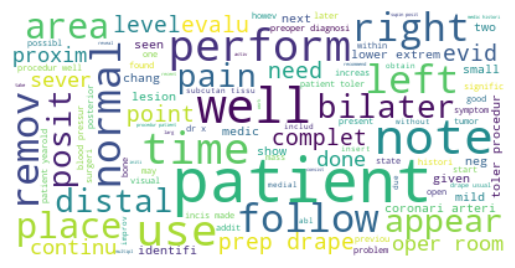

In [36]:
print_wordCloud(data['unigram'])

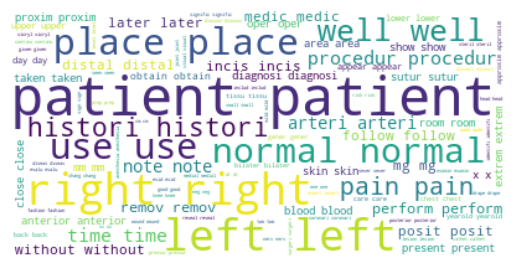

In [37]:
print_wordCloud(data['bigram'])

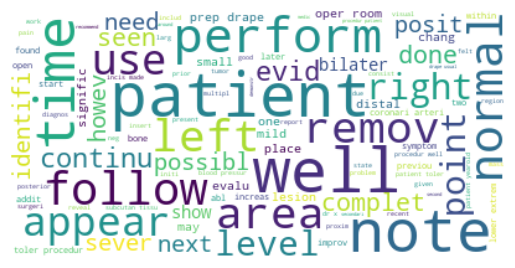

In [38]:
print_wordCloud(data['trigram'])

In [39]:
from collections import Counter
import matplotlib.pyplot as plt

def print_bar(data, ngram):

  # Initialize dictionaries to store word counts for each medical specialty
  word_counts = {specialty: Counter() for specialty in ['Orthopedic', 'Cardiovascular / Pulmonary', 'Consult - History and Phy.', 'Gastroenterology','Neurology']}

  # Count occurrences of words for each medical specialty
  for index, row in data.iterrows():
      specialty = row['medical_specialty']
      words = row[ngram]
      word_counts[specialty].update(words)

  # Convert dictionaries to DataFrames
  dfs = {specialty: pd.DataFrame(list(count.items()), columns=['Word', 'Count']).sort_values(by='Count', ascending=False) for specialty, count in word_counts.items()}

  # Get top 10 most frequent words for each category
  top_words = {specialty: df.head(10) for specialty, df in dfs.items()}

  fig, axes = plt.subplots(3, 2, figsize=(10, 10))

  for i, (specialty, top_words_df) in enumerate(top_words.items()):
      ax = axes[i // 2, i % 2]
      ax.bar(top_words_df['Word'], top_words_df['Count'], color='skyblue')
      ax.set_ylabel('Count')
      ax.set_title(f'Top 10 Words in {specialty}')
      ax.tick_params(axis='x', rotation=45, labelsize=8)
      ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)

  plt.tight_layout()
  plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

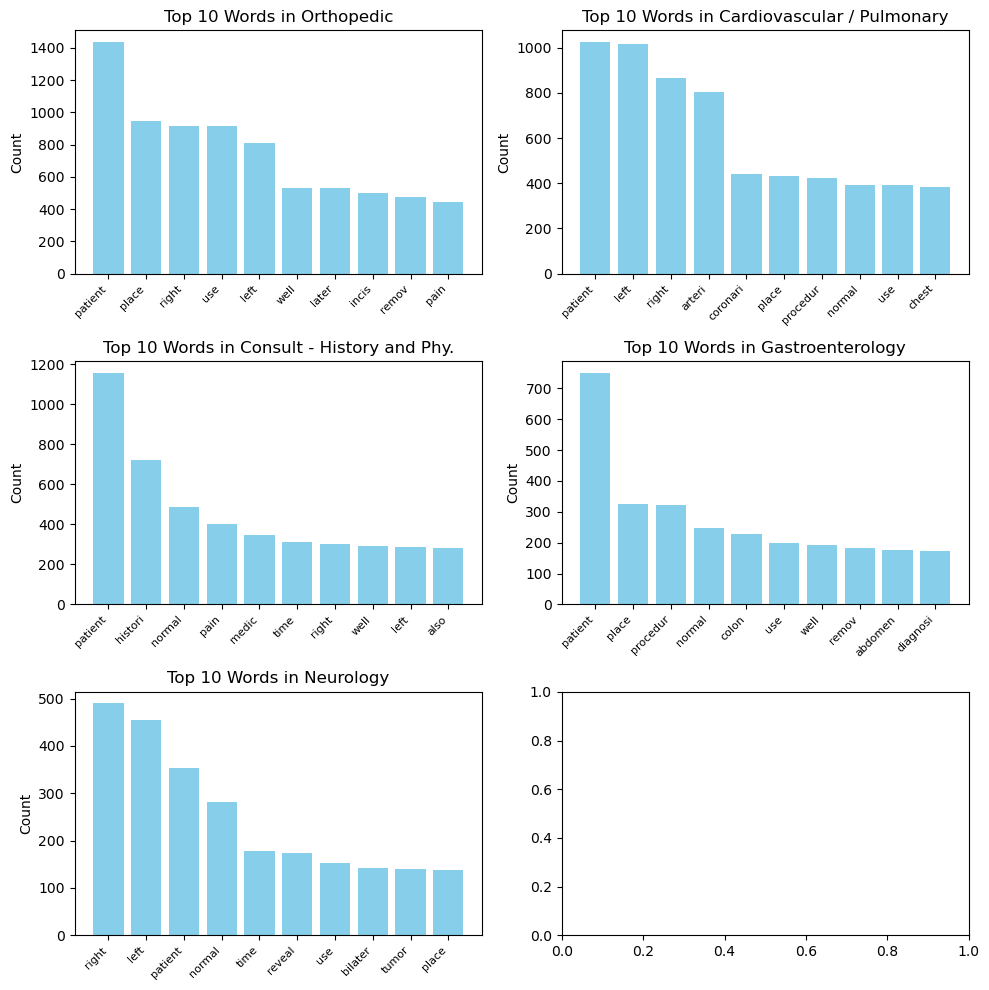

In [40]:
print_bar(data, 'unigram')

C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

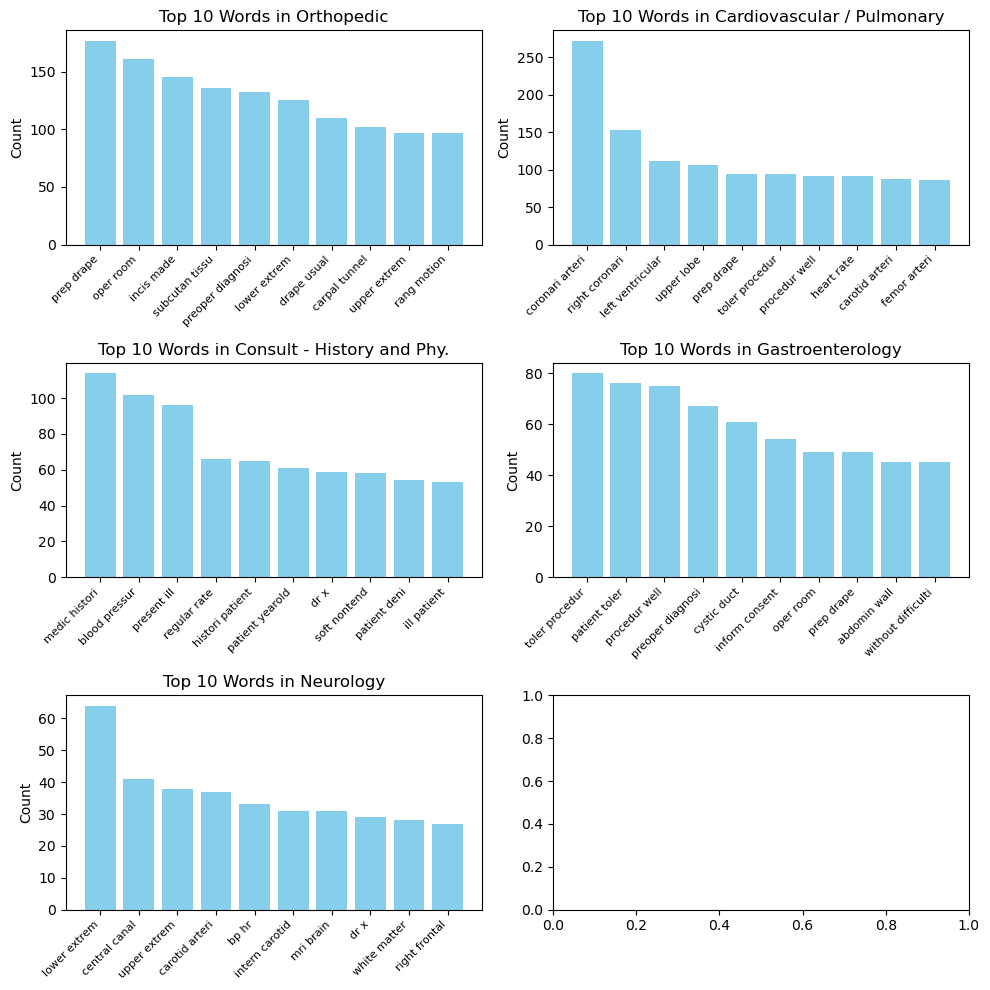

In [41]:
print_bar(data, 'bigram')

C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_words_df['Word'], rotation=45, ha='right', fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\3776283115.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

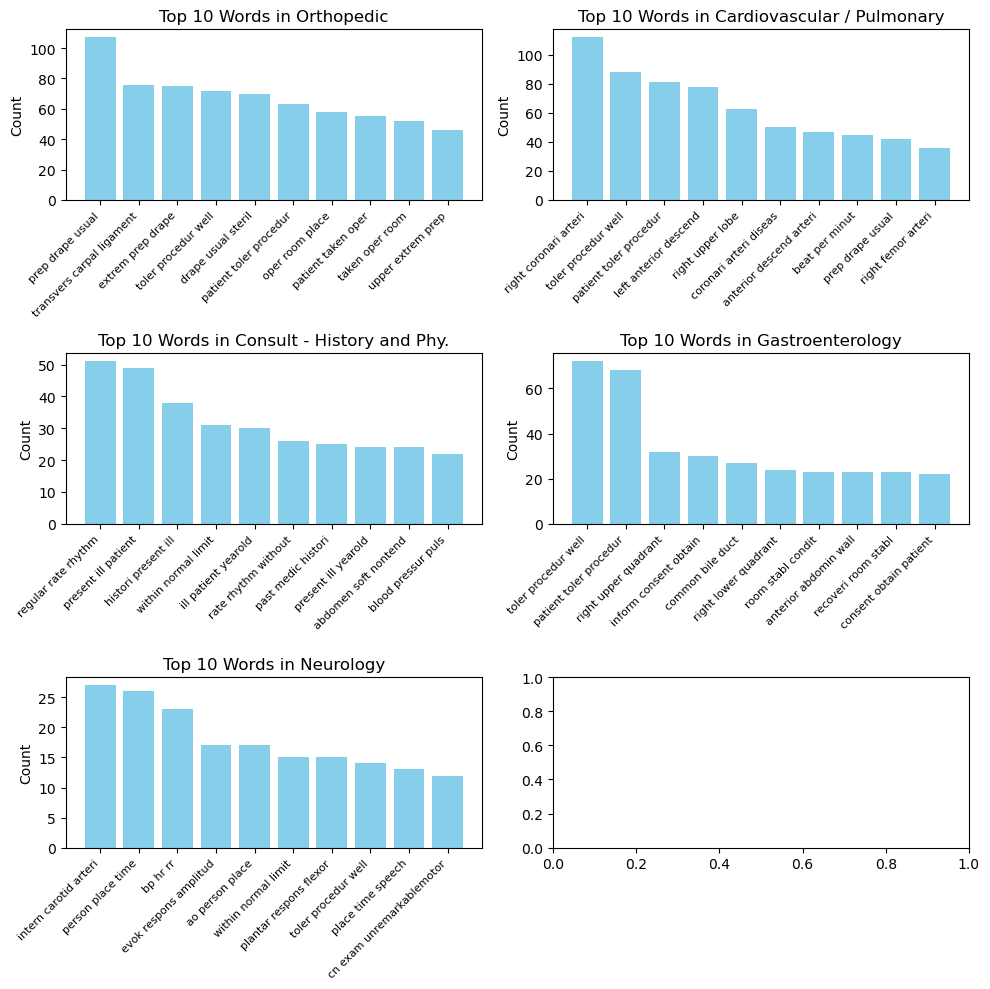

In [42]:
print_bar(data, 'trigram')

We notice that some words (eg. patient left right) are very frequent, we decided to find so the most **frequent words** and remove them as we did for the sotp words

In [43]:
from collections import Counter, defaultdict

threshold = 800

def print_frequent_words(list, threshold):

  strings = list.apply(lambda x: ' '.join(x))
  # Create a defaultdict for the word counts
  word_counts = defaultdict(int)
  for string in strings:
    for word in string.split():
      word_counts[word] += 1

  # Create a set of frequent words
  frequent_words = {word for word, count in word_counts.items() if count > threshold}


  return(frequent_words)

In [44]:
frequent = print_frequent_words(data['stemmed'], threshold)
print(frequent)

{'patient', 'left', 'well', 'normal', 'note', 'time', 'arteri', 'procedur', 'use', 'posit', 'remov', 'place', 'right', 'perform', 'histori', 'incis', 'also', 'pain'}


We make an exception for '**histori**' which can be rappresentative for the **Consult - Historic** category

In [45]:
frequent.remove('histori')

In [46]:
data['stemmed'] = data['stemmed'].apply(lambda x: ' '.join([word for word in x if word not in (frequent)]))
data['stemmed'] = data.apply(lambda row: nltk.word_tokenize(str(row['stemmed'])), axis=1)

Rebuild n-grams without frequent words

In [47]:
data['unigram'] = n_gram(1, data)
data['bigram'] = n_gram(2, data)
data['trigram'] = n_gram(3, data)

In [48]:
data.head()

,medical_specialty,transcription,tokenized_sents,stop_words,stemmed,unigram,bigram,trigram
3,Cardiovascular / Pulmonary,d mmode left atrial enlargement with left a...,"[d, mmode, left, atrial, enlargement, with, le...","[mmode, left, atrial, enlargement, left, atria...","[mmode, atrial, enlarg, atrial, diamet, cm, si...","[mmode, atrial, enlarg, atrial, diamet, cm, si...","[mmode atrial, atrial enlarg, enlarg atrial, a...","[mmode atrial enlarg, atrial enlarg atrial, en..."
4,Cardiovascular / Pulmonary,the left ventricular cavity size and wall th...,"[the, left, ventricular, cavity, size, and, wa...","[left, ventricular, cavity, size, wall, thickn...","[ventricular, caviti, size, wall, thick, appea...","[ventricular, caviti, size, wall, thick, appea...","[ventricular caviti, caviti size, size wall, w...","[ventricular caviti size, caviti size wall, si..."
7,Cardiovascular / Pulmonary,d echocardiogrammultiple views of the heart an...,"[d, echocardiogrammultiple, views, of, the, he...","[echocardiogrammultiple, views, heart, great, ...","[echocardiogrammultipl, view, heart, great, ve...","[echocardiogrammultipl, view, heart, great, ve...","[echocardiogrammultipl view, view heart, heart...","[echocardiogrammultipl view heart, view heart ..."
9,Cardiovascular / Pulmonary,description normal cardiac chambers size nor...,"[description, normal, cardiac, chambers, size,...","[description, normal, cardiac, chambers, size,...","[descript, cardiac, chamber, size, ventricular...","[descript, cardiac, chamber, size, ventricular...","[descript cardiac, cardiac chamber, chamber si...","[descript cardiac chamber, cardiac chamber siz..."
11,Cardiovascular / Pulmonary,d study mild aortic stenosis widely calcified ...,"[d, study, mild, aortic, stenosis, widely, cal...","[study, mild, aortic, stenosis, widely, calcif...","[studi, mild, aortic, stenosi, wide, calcifi, ...","[studi, mild, aortic, stenosi, wide, calcifi, ...","[studi mild, mild aortic, aortic stenosi, sten...","[studi mild aortic, mild aortic stenosi, aorti..."


## Classification models
## Importing libraries

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn import metrics

In [50]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### Visualization functions

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Define a function to plot learning curves
def plot_learning_curves(model, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', cv=5
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title('Learning Curves')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color='blue')
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training Accuracy')
    plt.plot(train_sizes, val_scores_mean, 'o-', color='orange', label='Validation Accuracy')

    plt.legend()
    plt.grid()
    plt.show()



### Defining dataframe for classification

In [53]:
data_cl = data[['stemmed', 'medical_specialty']]

In [54]:
def untokanize(row):
    return ' '.join(row)

# Applying the untokanize function to the specified column
data_cl['stemmed'] = data_cl['stemmed'].apply(untokanize)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15644\267845966.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cl['stemmed'] = data_cl['stemmed'].apply(untokanize)


In [55]:
data_cl.head()

,stemmed,medical_specialty
3,mmode atrial enlarg atrial diamet cm size vent...,Cardiovascular / Pulmonary
4,ventricular caviti size wall thick appear wall...,Cardiovascular / Pulmonary
7,echocardiogrammultipl view heart great vessel ...,Cardiovascular / Pulmonary
9,descript cardiac chamber size ventricular size...,Cardiovascular / Pulmonary
11,studi mild aortic stenosi wide calcifi minim r...,Cardiovascular / Pulmonary


### Train - Test split

In [56]:
X = data_cl['stemmed'].values  # List of texts
y = data_cl['medical_specialty'].values  # List of corresponding labels

# 'y' contains labels in string format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Create a dictionary mapping original categories to encoded labels
category_to_label = {category: label for category, label in zip(y, y_encoded)}

# Define a custom mapping for specific labels
custom_labels = {
    0: 'Cardiovascular / Pulmonary',
    1: 'Orthopedic',
    2: 'Neurology',
    3: 'Gastroenterology',
    4: 'Consult - History and Phy.'
}

# Create a dictionary to map encoded labels to custom labels
label_to_custom = {label: custom_labels.get(label, f'Label_{label}') for label in set(y_encoded)}

# Data Split with Original Title Split into training & test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=0)

# Print the mapping of encoded labels to custom labels
for label, custom_label in label_to_custom.items():
    print(f"Label: {label} -> Custom Label: {custom_label}")


Label: 0 -> Custom Label: Cardiovascular / Pulmonary
Label: 1 -> Custom Label: Orthopedic
Label: 2 -> Custom Label: Neurology
Label: 3 -> Custom Label: Gastroenterology
Label: 4 -> Custom Label: Consult - History and Phy.


In [57]:
print(f"Number of elements in training set: {X_train.size}")
print(f"Number of elements in test set: {X_test.size}")

Number of elements in training set: 944
Number of elements in test set: 236


### Logistic regression using tf-idf

In [58]:
tfidf_vectorizer = TfidfVectorizer(use_idf=True)
X_train_vectors_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_vectors_tfidf = tfidf_vectorizer.transform(X_test)

In [59]:
#FITTING THE CLASSIFICATION MODEL using Logistic Regression(tf-idf)
lr_tfidf=LogisticRegression(solver = 'liblinear', C=10, penalty = 'l2')
lr_tfidf.fit(X_train_vectors_tfidf, y_train)
#Predict y value for test dataset
y_predict = lr_tfidf.predict(X_test_vectors_tfidf)
y_prob = lr_tfidf.predict_proba(X_test_vectors_tfidf)[:,1]
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88        57
           1       0.59      0.66      0.62        50
           2       0.97      0.73      0.83        48
           3       0.48      0.44      0.46        32
           4       0.74      0.82      0.78        49

    accuracy                           0.74       236
   macro avg       0.73      0.71      0.71       236
weighted avg       0.75      0.74      0.74       236



c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


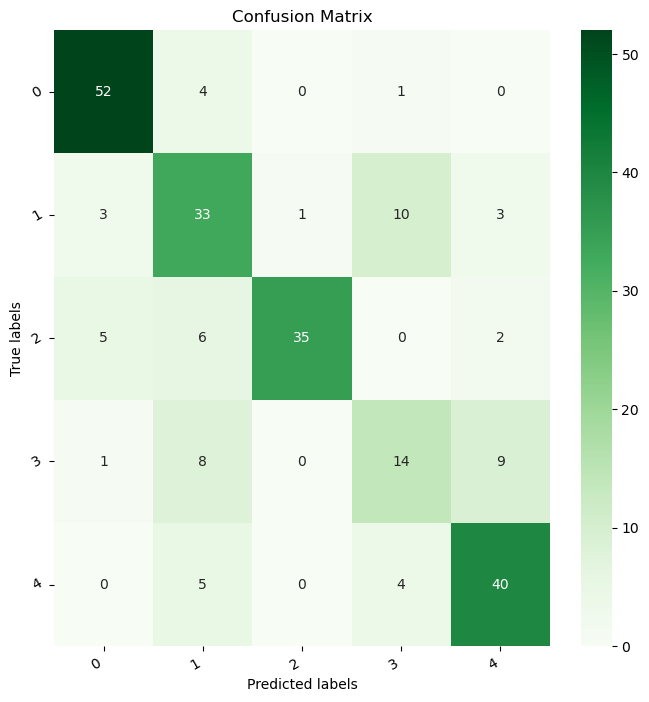

In [60]:
import seaborn as sns
fig = plt.figure(figsize=(8,8))
ax= fig.add_subplot(1,1,1)
cm = metrics.confusion_matrix(y_test,y_predict)
sns.heatmap(cm, annot=True, cmap="Greens",ax = ax,fmt='g'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
#ax.xaxis.set_ticklabels(labels); ax.yaxis.set_ticklabels(labels);
plt.setp(ax.get_yticklabels(), rotation=30, horizontalalignment='right')
plt.setp(ax.get_xticklabels(), rotation=30, horizontalalignment='right')
plt.show()

In [61]:
from sklearn.metrics import log_loss
# Assuming lr_tfidf is already defined and trained
# Predict probabilities on the training set
train_probs = lr_tfidf.predict_proba(X_train_vectors_tfidf)

# Calculate log loss on the training set
train_loss = log_loss(y_train, train_probs)

# Predict probabilities on the test set
test_probs = lr_tfidf.predict_proba(X_test_vectors_tfidf)

# Calculate log loss on the test set
test_loss = log_loss(y_test, test_probs)

# Print the log loss on train and test sets
print(f"Log Loss on Training Set: {train_loss}")
print(f"Log Loss on Test Set: {test_loss}")

Log Loss on Training Set: 0.21519285173775524
Log Loss on Test Set: 0.6196121916736949


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinom

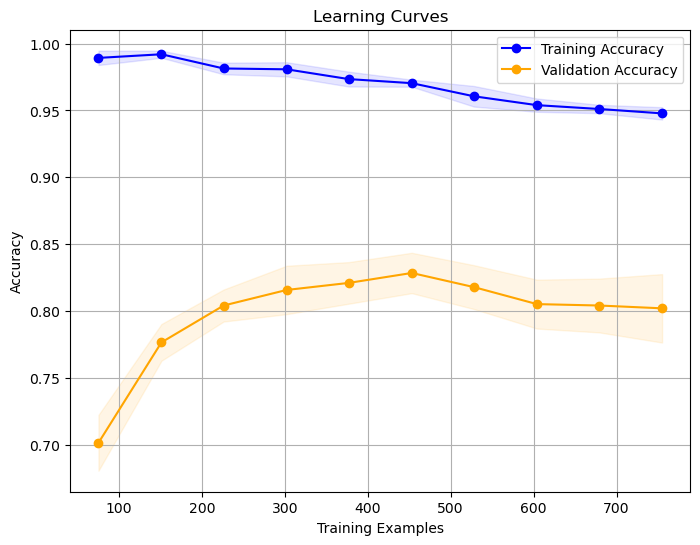

In [62]:
# Plot learingn curves of Logistic Regression
plot_learning_curves(lr_tfidf, X_train_vectors_tfidf, y_train)

### Naive Bayes Tf-Idf

In [63]:
#FITTING THE CLASSIFICATION MODEL using Naive Bayes(tf-idf)
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_vectors_tfidf, y_train)
#Predict y value for test dataset
y_predict = nb_tfidf.predict(X_test_vectors_tfidf)
y_prob = nb_tfidf.predict_proba(X_test_vectors_tfidf)[:,1]
print(classification_report(y_test,y_predict))
#print('Confusion Matrix:',confusion_matrix(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        57
           1       0.63      0.78      0.70        50
           2       1.00      0.58      0.74        48
           3       0.75      0.47      0.58        32
           4       0.65      0.92      0.76        49

    accuracy                           0.75       236
   macro avg       0.78      0.72      0.73       236
weighted avg       0.78      0.75      0.74       236



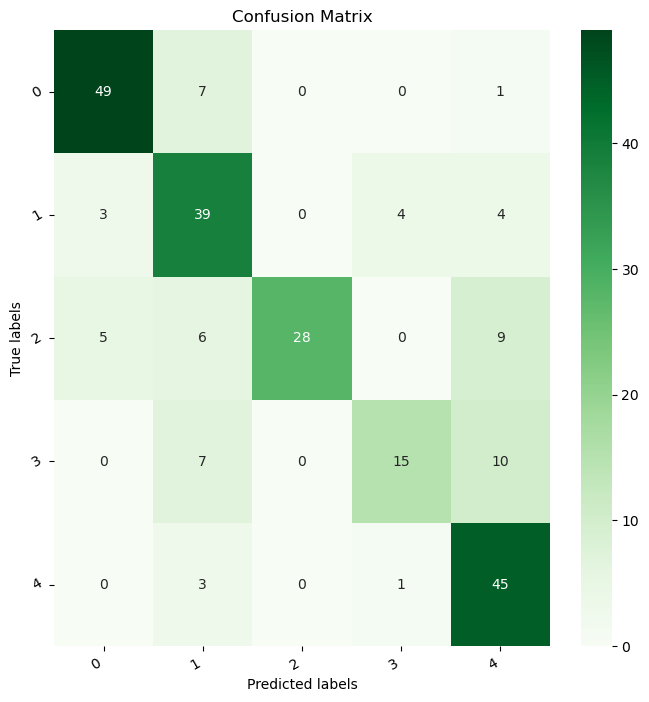

In [64]:
import seaborn as sns
fig = plt.figure(figsize=(8,8))
ax= fig.add_subplot(1,1,1)
cm = metrics.confusion_matrix(y_test,y_predict)
sns.heatmap(cm, annot=True, cmap="Greens",ax = ax,fmt='g'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
#ax.xaxis.set_ticklabels(labels); ax.yaxis.set_ticklabels(labels);
plt.setp(ax.get_yticklabels(), rotation=30, horizontalalignment='right')
plt.setp(ax.get_xticklabels(), rotation=30, horizontalalignment='right')
plt.show()

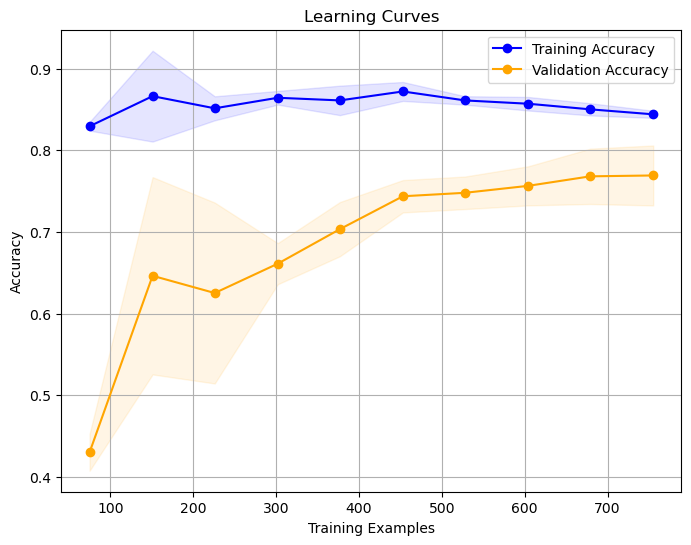

In [65]:
# Plot learingn curves of Naive Bayes
plot_learning_curves(nb_tfidf, X_train_vectors_tfidf, y_train)

### Random Forest

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)), # random state utile per la riproducibilità e la comparabilità dei risultati.
])


text_clf.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [67]:
from sklearn.metrics import accuracy_score, classification_report
predictions = text_clf.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:\n', classification_report(y_test, predictions))

Accuracy: 0.70

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86        57
           1       0.55      0.64      0.59        50
           2       0.97      0.69      0.80        48
           3       0.44      0.38      0.41        32
           4       0.66      0.76      0.70        49

    accuracy                           0.70       236
   macro avg       0.69      0.67      0.67       236
weighted avg       0.71      0.70      0.70       236



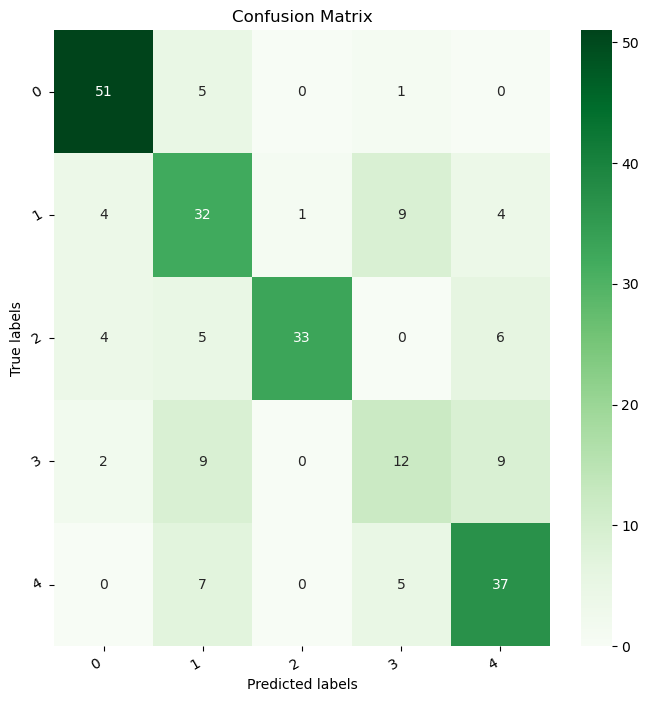

In [68]:
import seaborn as sns
fig = plt.figure(figsize=(8,8))
ax= fig.add_subplot(1,1,1)
cm = metrics.confusion_matrix(y_test,predictions)
sns.heatmap(cm, annot=True, cmap="Greens",ax = ax,fmt='g'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
#ax.xaxis.set_ticklabels(labels); ax.yaxis.set_ticklabels(labels);
plt.setp(ax.get_yticklabels(), rotation=30, horizontalalignment='right')
plt.setp(ax.get_xticklabels(), rotation=30, horizontalalignment='right')
plt.show()

In [69]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'tfidf__max_features': [1000, 2000, 3000],
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [None, 10, 20],
}

# new pipeline with TfidfVectorizer e RandomForestClassifier
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(random_state=42)),
])

#  GridSearchCV
grid_search = GridSearchCV(text_clf, param_grid, cv=5, n_jobs=-1, verbose=1)


grid_search.fit(X_train, y_train)

# Best hyperparameter
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


best_model = grid_search.best_estimator_
test_predictions = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
print("Test Accuracy with Best Model:", test_accuracy)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


PicklingError: Could not pickle the task to send it to the workers.

In [ ]:
print(type(X_train))
print(X_train.shape if hasattr(X_train, 'shape') else len(X_train))

<class 'numpy.ndarray'>
(944,)


### BERT

In [ ]:
pip install transformers

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.6 MB 10.8 MB/s eta 0:00:01
   -------------- ------------------------- 4.5/12.6 MB 11.7 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.6 MB 11.8 MB/s eta 0:00:01
   ------------------------------ --------- 9.7/12.6 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 11.3 MB/s  0:00:01
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ------------------------ --------------- 2.4/3.8 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 10.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   -------------------------------- ------- 2.4/2.9 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 10.8 MB/s  0:00:00
   --------------------

  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


In [ ]:
%pip install torch transformers tqdm ipywidgets
import torch
from tqdm.notebook import tqdm

from transformers import BertTokenizer
from torch.utils.data import TensorDataset

from transformers import BertForSequenceClassification

   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


#### Creating new dataframe

In [ ]:
df = data[['stemmed', 'medical_specialty']]

In [ ]:
df['stemmed'] = df['stemmed'].apply(untokanize)

C:\Users\DELL\AppData\Local\Temp\ipykernel_13232\3168691562.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stemmed'] = df['stemmed'].apply(untokanize)


In [ ]:
# Creates labels to idetify medical_specialty

possible_labels = df.medical_specialty.unique()

label_dict = {}
for index, possible_label in enumerate(possible_labels):
    label_dict[possible_label] = index
label_dict

{'Cardiovascular / Pulmonary': 0,
 'Orthopedic': 1,
 'Neurology': 2,
 'Gastroenterology': 3,
 'Consult - History and Phy.': 4}

In [ ]:
df['label'] = df.medical_specialty.replace(label_dict)

C:\Users\DELL\AppData\Local\Temp\ipykernel_13232\2060020197.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df.medical_specialty.replace(label_dict)
C:\Users\DELL\AppData\Local\Temp\ipykernel_13232\2060020197.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df.medical_specialty.replace(label_dict)


#### Train test split of the dataframe

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(df.index.values,
                                                  df.label.values,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=df.label.values)

df['data_type'] = ['not_set']*df.shape[0]

df.loc[X_train, 'data_type'] = 'train'
df.loc[X_val, 'data_type'] = 'val'

df.groupby(['medical_specialty', 'label', 'data_type']).count()

C:\Users\DELL\AppData\Local\Temp\ipykernel_13232\1508733431.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['data_type'] = ['not_set']*df.shape[0]


stemmed
medical_specialty          label data_type         
Cardiovascular / Pulmonary 0     train          224
                                 val             56
Consult - History and Phy. 4     train          187
                                 val             47
Gastroenterology           3     train          156
                                 val             39
Neurology                  2     train          135
                                 val             33
Orthopedic                 1     train          242
                                 val             61

### Model building

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

encoded_data_train = tokenizer(
    df[df.data_type == 'train'].stemmed.astype(str).tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    max_length=256,
    truncation=True,
    return_tensors='pt'
)

encoded_data_val = tokenizer(
    df[df.data_type == 'val'].stemmed.astype(str).tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    max_length=256,
    truncation=True,
    return_tensors='pt'
)

input_ids_train = encoded_data_train['input_ids']
attention_masks_train = encoded_data_train['attention_mask']
input_ids_val = encoded_data_val['input_ids']
attention_masks_val = encoded_data_val['attention_mask']
labels_train = torch.tensor(df[df.data_type=='train'].label.values)

input_ids_val = encoded_data_val['input_ids']
attention_masks_val = encoded_data_val['attention_mask']
labels_val = torch.tensor(df[df.data_type=='val'].label.values)

dataset_train = TensorDataset(input_ids_train, attention_masks_train, labels_train)
dataset_val = TensorDataset(input_ids_val, attention_masks_val, labels_val)

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased",
                                                      num_labels=len(label_dict),
                                                      output_attentions=False,
                                                      output_hidden_states=False)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\DELL\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

batch_size = 8

dataloader_train = DataLoader(dataset_train,
                              sampler=RandomSampler(dataset_train),
                              batch_size=batch_size)

dataloader_validation = DataLoader(dataset_val,
                                   sampler=SequentialSampler(dataset_val),
                                   batch_size=batch_size)

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(),
                  lr=1e-5,
                  eps=1e-8)

epochs = 5

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=len(dataloader_train) * epochs
)

#### Evaluatin functions

In [ ]:
def single_training_epoch(model, optimizer, train_dataloader):
    model.train()
    # Loop over the training set
    for input_ids, attention_masks, labels in train_dataloader:
        # Clear the gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(input_ids, attention_mask=attention_masks, labels=labels)
        loss = outputs[0]
        # Backward pass
        loss.backward()
        optimizer.step()
    return model, optimizer

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def acc_func(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return accuracy_score(labels_flat, preds_flat)

def f1_score_func(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return f1_score(labels_flat, preds_flat, average='weighted')

def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}

    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat==label]
        y_true = labels_flat[labels_flat==label]
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds==label])}/{len(y_true)}\n')

In [ ]:
from sklearn.metrics import roc_curve

In [ ]:
def evaluate_bert_model_one(preds, labels, model_name="model"):
  y = np.argmax(preds, axis=1).flatten()
  y_pred = labels.flatten()

  print('Validation Set')
  print("Accuracy:", accuracy_score(y, y_pred))
  print()
  print(classification_report(y, y_pred, digits=4))
  cm = confusion_matrix(y, y_pred)
  plt.figure(figsize=(10,10))
  ax = sns.heatmap(cm, annot=True, cmap=plt.cm.Greens, square=True)
  ax.set_xlabel('Predicted label')
  ax.set_ylabel('True label')
  plt.savefig(model_name + "_" + 'validation' + ".eps")
  plt.show()

In [ ]:
# model, optimizer =  single_training_epoch(model, optimizer, dataloader_train)
# Selecting 'cuda' (GPU) as device tu run the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(device)